# DQN O-RAN PRB Scheduler — Results

Generates all four deliverable plots:
1. **Throughput comparison** — 3 schedulers × 3 scenarios
2. **DQN training reward curve** — episode reward over training steps
3. **PRB allocation heatmap** — per-UE allocation over time (heterogeneous)
4. **Jain's Fairness Index** — all schedulers × all scenarios


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from env.ran_environment import RANEnvironment
from agent.dqn_agent     import DQNAgent
from eval.baselines       import round_robin, proportional_fair
from eval.metrics         import compute_throughput, jains_fairness

matplotlib.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
})

SCENARIOS  = ['uniform', 'heterogeneous', 'bursty']
SCHEDULERS = ['Round-Robin', 'Prop-Fair', 'DQN']
N_UES      = 5
TOTAL_PRBS = 50
EVAL_STEPS = 500
MODEL_DIR  = '../models'
BAR_COLORS = ['#4C72B0', '#DD8452', '#55A868']

print('Imports OK')


Imports OK


In [2]:
def evaluate_scheduler(scenario, scheduler_name, steps=EVAL_STEPS, seed=42):
    env = RANEnvironment(scenario=scenario, max_steps=steps)
    state, _ = env.reset(seed=seed)

    agent = None
    if scheduler_name == 'DQN':
        agent = DQNAgent()
        model_path = os.path.join(MODEL_DIR, f'dqn_trained_{scenario}.pt')
        if os.path.exists(model_path):
            agent.load(model_path)
        else:
            print(f'  [warn] No model at {model_path}; using untrained weights')

    all_throughputs, all_fairness, all_prb_alloc, all_cqi = [], [], [], []

    for _ in range(steps):
        if scheduler_name == 'Round-Robin':
            action = np.array(round_robin(N_UES, TOTAL_PRBS), dtype=np.float32)
        elif scheduler_name == 'Prop-Fair':
            action = proportional_fair(state, N_UES, TOTAL_PRBS)
        else:
            # act() returns (index, prb_allocation_vector)
            _, action = agent.act(state, epsilon=0.0)

        state, _, terminated, truncated, info = env.step(action)
        tput = np.array(info['throughputs'])
        all_throughputs.append(tput)
        all_fairness.append(jains_fairness(tput))
        all_prb_alloc.append(env.prb_alloc.copy())
        all_cqi.append(np.array(info['cqi']))

        if terminated or truncated:
            state, _ = env.reset(seed=seed)

    return {
        'throughputs': np.array(all_throughputs),
        'fairness':    np.array(all_fairness),
        'prb_alloc':   np.array(all_prb_alloc),
        'cqi':         np.array(all_cqi),
    }


print('Running evaluations (9 combinations)...')
results = {}
for scenario in SCENARIOS:
    results[scenario] = {}
    for sched in SCHEDULERS:
        print(f'  {scenario:>14s} x {sched}')
        results[scenario][sched] = evaluate_scheduler(scenario, sched)
print('Done.')


Running evaluations (9 combinations)...
         uniform x Round-Robin
         uniform x Prop-Fair
         uniform x DQN


   heterogeneous x Round-Robin
   heterogeneous x Prop-Fair
   heterogeneous x DQN


          bursty x Round-Robin
          bursty x Prop-Fair
          bursty x DQN


Done.


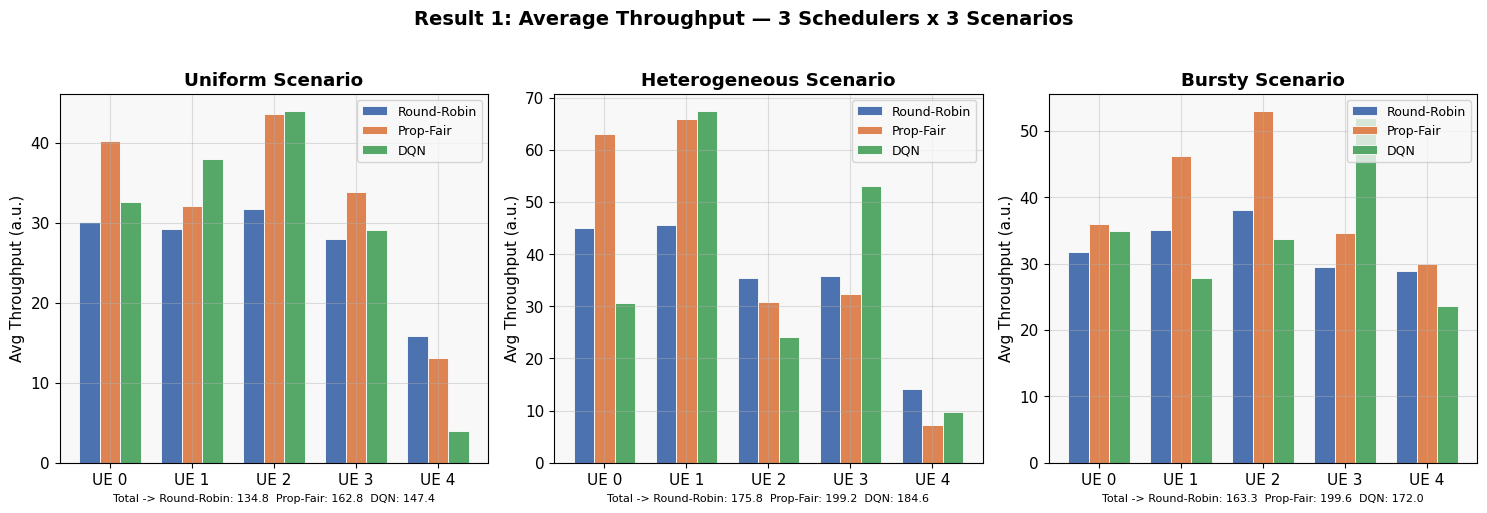

Saved result1_throughput.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle('Result 1: Average Throughput — 3 Schedulers x 3 Scenarios',
             fontsize=14, fontweight='bold', y=1.02)

x     = np.arange(N_UES)
width = 0.25

for col, scenario in enumerate(SCENARIOS):
    ax = axes[col]
    for i, sched in enumerate(SCHEDULERS):
        avg_tput = results[scenario][sched]['throughputs'].mean(axis=0)
        ax.bar(x + (i - 1) * width, avg_tput, width,
               label=sched, color=BAR_COLORS[i], edgecolor='white', linewidth=0.6)

    ax.set_title(f'{scenario.capitalize()} Scenario', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'UE {i}' for i in range(N_UES)])
    ax.set_ylabel('Avg Throughput (a.u.)')
    ax.legend(fontsize=9)

    totals = [results[scenario][s]['throughputs'].mean(axis=0).sum()
              for s in SCHEDULERS]
    total_str = '  '.join(f'{s}: {t:.1f}' for s, t in zip(SCHEDULERS, totals))
    ax.set_xlabel(f'Total -> {total_str}', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'result1_throughput.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved result1_throughput.png')


In [4]:
from agent.replay_buffer import ReplayBuffer

def record_training_curve(scenario, total_steps=50_000, batch_size=64, seed=0):
    env    = RANEnvironment(scenario=scenario)
    agent  = DQNAgent()
    buffer = ReplayBuffer(50_000)
    eps, eps_min, eps_decay = 1.0, 0.05, 0.9997
    warmup   = 500
    step_log, reward_log = [], []
    ep_reward = 0.0
    state, _ = env.reset(seed=seed)

    for t in range(1, total_steps + 1):
        idx, alloc = agent.act(state, eps)
        ns, r, term, trunc, _ = env.step(alloc)
        done = term or trunc
        buffer.push(state, idx, r, ns, done)
        ep_reward += r
        eps = max(eps_min, eps * eps_decay)
        if t >= warmup and len(buffer) >= batch_size:
            agent.learn(buffer.sample(batch_size))
        if done:
            step_log.append(t)
            reward_log.append(ep_reward)
            ep_reward = 0.0
            state, _ = env.reset()
        else:
            state = ns

    return np.array(step_log), np.array(reward_log)


print('Recording training curves (3 scenarios x 50,000 steps each)...')
curves = {}
for sc in SCENARIOS:
    print(f'  {sc}')
    curves[sc] = record_training_curve(sc)
print('Done.')


Recording training curves (3 scenarios x 50,000 steps each)...
  uniform


  heterogeneous


  bursty


Done.


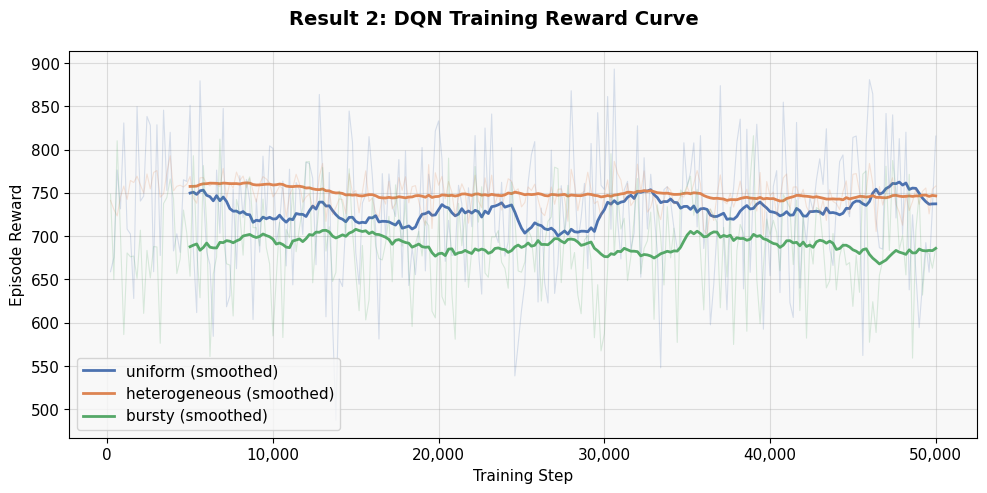

Saved result2_training_curve.png


In [5]:
def smooth(y, window=5):
    if len(y) < window:
        return y
    return np.convolve(y, np.ones(window) / window, mode='valid')

sc_colors = {'uniform': '#4C72B0', 'heterogeneous': '#DD8452', 'bursty': '#55A868'}

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Result 2: DQN Training Reward Curve', fontsize=14, fontweight='bold')

for sc in SCENARIOS:
    steps, rewards = curves[sc]
    w  = max(3, len(rewards) // 10)
    sm = smooth(rewards, window=w)
    ax.plot(steps, rewards, alpha=0.2, color=sc_colors[sc], linewidth=0.8)
    ax.plot(steps[w - 1:], sm, label=f'{sc} (smoothed)',
            color=sc_colors[sc], linewidth=2.0)

ax.set_xlabel('Training Step')
ax.set_ylabel('Episode Reward')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'result2_training_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved result2_training_curve.png')


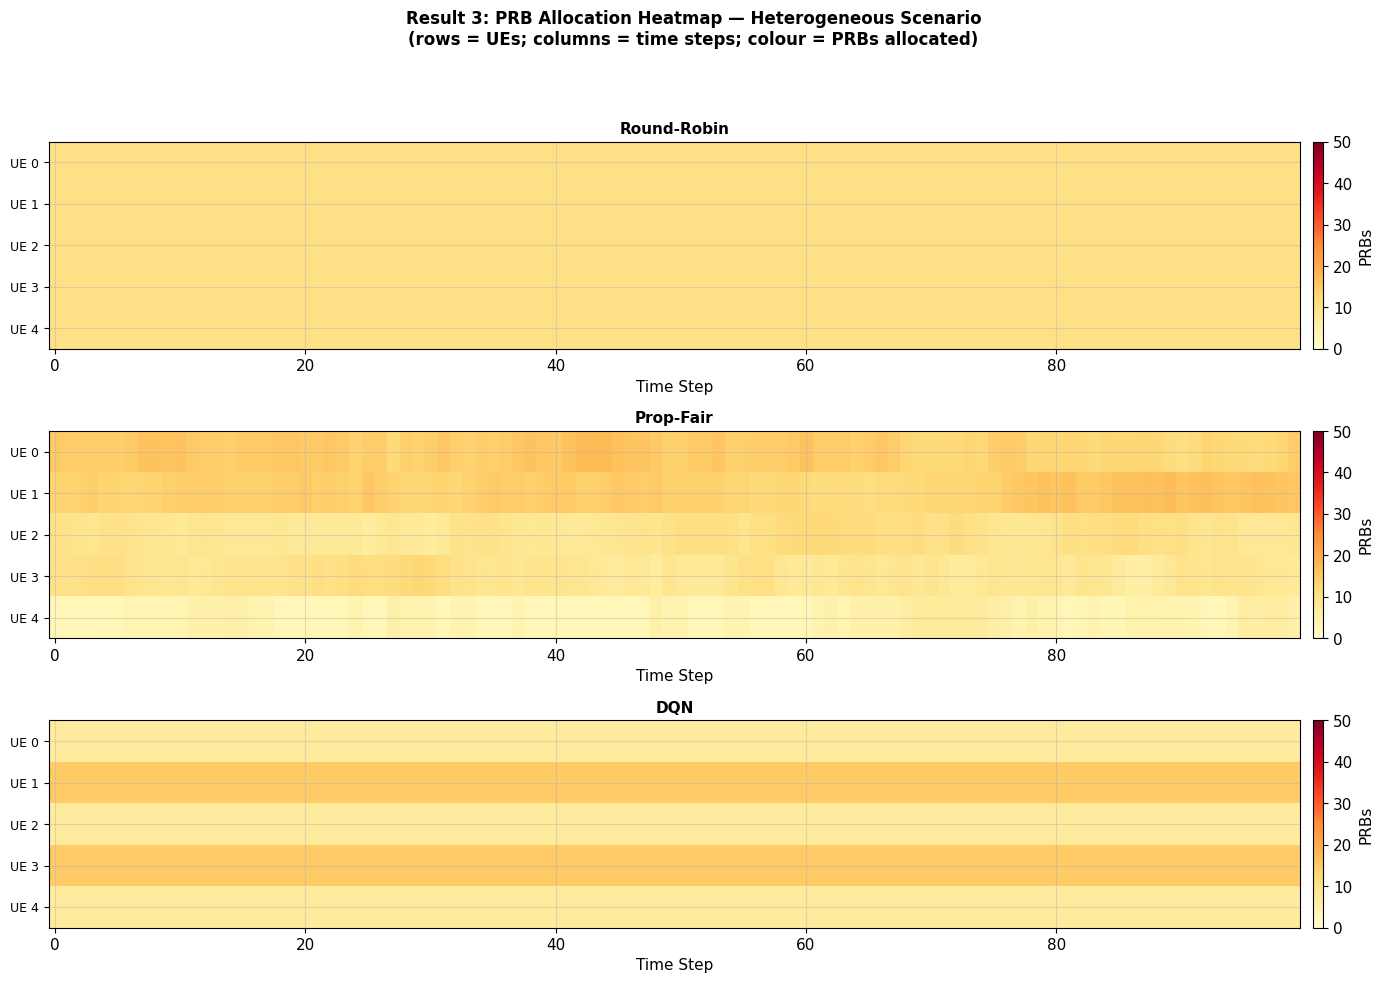

Saved result3_prb_heatmap.png


In [6]:
HEATMAP_STEPS = 100

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle(
    'Result 3: PRB Allocation Heatmap — Heterogeneous Scenario\n'
    '(rows = UEs; columns = time steps; colour = PRBs allocated)',
    fontsize=12, fontweight='bold'
)

for row, sched in enumerate(SCHEDULERS):
    ax   = axes[row]
    data = results['heterogeneous'][sched]['prb_alloc'][:HEATMAP_STEPS].T
    im   = ax.imshow(data, aspect='auto', cmap='YlOrRd',
                     vmin=0, vmax=TOTAL_PRBS, interpolation='nearest')
    ax.set_yticks(range(N_UES))
    ax.set_yticklabels([f'UE {i}' for i in range(N_UES)], fontsize=9)
    ax.set_xlabel('Time Step')
    ax.set_title(sched, fontweight='bold', fontsize=11)
    plt.colorbar(im, ax=ax, label='PRBs', fraction=0.015, pad=0.01)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(os.path.join(MODEL_DIR, 'result3_prb_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved result3_prb_heatmap.png')


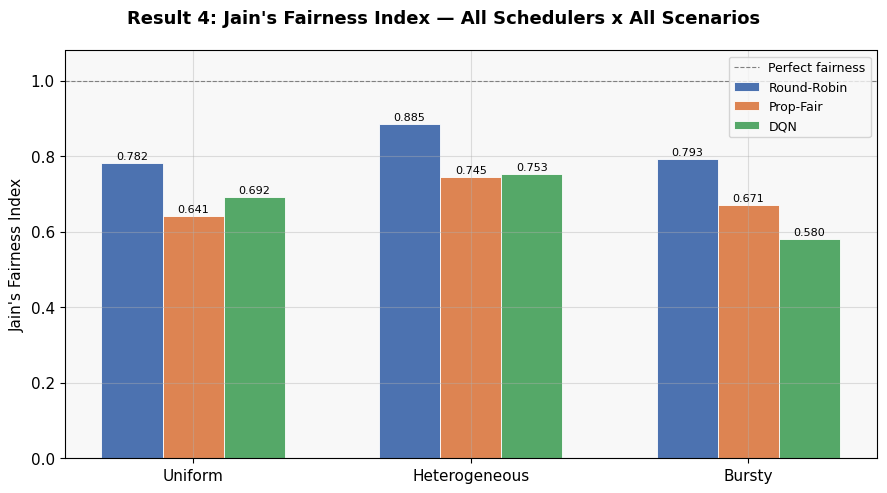

Saved result4_jains_fairness.png


In [7]:
jain_matrix = np.zeros((len(SCENARIOS), len(SCHEDULERS)))
for i, sc in enumerate(SCENARIOS):
    for j, sched in enumerate(SCHEDULERS):
        jain_matrix[i, j] = results[sc][sched]['fairness'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Result 4: Jain's Fairness Index — All Schedulers x All Scenarios",
             fontsize=13, fontweight='bold')

x     = np.arange(len(SCENARIOS))
width = 0.22
for j, (sched, color) in enumerate(zip(SCHEDULERS, BAR_COLORS)):
    vals = jain_matrix[:, j]
    bars = ax.bar(x + (j - 1) * width, vals, width,
                  label=sched, color=color, edgecolor='white', linewidth=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.004,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in SCENARIOS])
ax.set_ylabel("Jain's Fairness Index")
ax.set_ylim(0, 1.08)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='Perfect fairness')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'result4_jains_fairness.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved result4_jains_fairness.png")


In [8]:
col_w = [16, 14, 16, 13]
print('=' * 63)
print('SUMMARY')
print('=' * 63)
print(f"{'Scenario':>{col_w[0]}} {'Scheduler':>{col_w[1]}} {'Avg Total Tput':>{col_w[2]}} {'Jains Index':>{col_w[3]}}")
print('-' * 63)
for sc in SCENARIOS:
    for sched in SCHEDULERS:
        tput = results[sc][sched]['throughputs'].sum(axis=1).mean()
        jain = results[sc][sched]['fairness'].mean()
        print(f'{sc:>{col_w[0]}} {sched:>{col_w[1]}} {tput:>{col_w[2]}.2f} {jain:>{col_w[3]}.4f}')
    print('-' * 63)


SUMMARY
        Scenario      Scheduler   Avg Total Tput   Jains Index
---------------------------------------------------------------
         uniform    Round-Robin           134.82        0.7823
         uniform      Prop-Fair           162.79        0.6414
         uniform            DQN           147.43        0.6919
---------------------------------------------------------------
   heterogeneous    Round-Robin           175.78        0.8855
   heterogeneous      Prop-Fair           199.23        0.7445
   heterogeneous            DQN           184.60        0.7529
---------------------------------------------------------------
          bursty    Round-Robin           163.31        0.7935
          bursty      Prop-Fair           199.58        0.6707
          bursty            DQN           172.02        0.5802
---------------------------------------------------------------
